<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
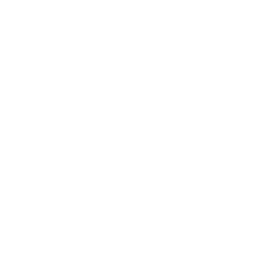
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kundriskprofilering via kanonisk diskriminering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finansiella tjänster / Kreditriskanalys &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Tre grupper med olika lånestatus i en portfölj av bolån till privatpersoner — **fallerade** (`DEFAULT`), **löpande** (`CURRENT`) och **förtidsåterbetalda** (`PREPAID`) — skiljer sig åt längs flera dimensioner av finansiell hälsa samtidigt, vilket gör att ett enskilt nyckeltal blir en svag risksignal. Den här notebooken tillämpar **PROC CANDISC** (kanonisk diskriminantanalys) på ett urval för riskgranskning med 100 kunder och kondenserar sex korrelerade finansiella nyckeltal till två kanoniska dimensioner som maximerar separationen mellan de tre statusgrupperna.

Den första kanoniska dimensionen bär nästan hela separationen mellan grupperna — kanonisk korrelation **0.958**, som delar **91.8%** av sin varians med grupptillhörighet — och ordnar låntagarna rent från fallerade i den ena ytterkanten till förtidsåterbetalda i den andra. Den andra dimensionen (kanonisk korrelation **0.503**, kvadrerad **0.254**) lägger till en sekundär kontrast som drivs av betalningsdröjsmålshistorik och skuldsättning. Kvadrerade Mahalanobisavstånd bekräftar att centroiderna för **DEFAULT** och **PREPAID** är det par som är mest åtskilt (**75.3**), medan **CURRENT** ligger mellan dem (34.3 från DEFAULT, 10.1 från PREPAID). De resulterande kanoniska poängen bildar ett kompakt sammansatt riskindex som lämpar sig för portföljsegmentering och kalibrering av scorekort.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Syntetiska finansiella nyckeltal och beteendemått för kunder, märkta med lånestatus, dragna som ett balanserat urval för riskgranskning | 100 |

Urvalet överrepresenterar medvetet fallerade och förtidsåterbetalda konton (ett urval av fall–kontroll-typ) så att varje statusgrupp är tillräckligt stor för att skatta en stabil kovariansstruktur inom grupperna för diskriminantanalysen.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic loan-customer risk-review sample.
   Three status groups (DEFAULT / CURRENT / PREPAID) are
   over-sampled toward the risk tails so each class is large
   enough for a stable within-group covariance estimate.
   -------------------------------------------------------- */
data work.loan_profiles;
    CALL streaminit(42);
    LÄNGD loan_status $10 vintage $7 customer_id $12;
    FÄLT statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    FÄLT vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    ETIKETT loan_status='Lånestatus' vintage='Årgång'
        dti_ratio='Skuld/inkomst-kvot' ltv_ratio='Belåningsgrad (LTV)'
        payment_to_income='Betalning/inkomst-kvot'
        credit_utilization='Kreditutnyttjande'
        savings_balance='Sparande (saldo)'
        months_delinquent='Månader i dröjsmål';
    GÖR i = 1 TILL 20000;
        customer_id = cat('CUST-', SKRIV_UT_V(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        OM status_prob < 0.30 SÅ status_idx = 1;       /* DEFAULT */
        ANNARS OM status_prob < 0.70 SÅ status_idx = 2;  /* CURRENT */
        ANNARS status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Financial ratios separate the three status groups */
        OM loan_status = 'DEFAULT' SÅ GÖR;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        SLUT;
        ANNARS OM loan_status = 'CURRENT' SÅ GÖR;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        SLUT;
        ANNARS GÖR;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        SLUT;
        /* Round and constrain ratios to valid ranges */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        OM dti_ratio < 0.05 SÅ dti_ratio = 0.05;
        OM dti_ratio > 0.99 SÅ dti_ratio = 0.99;
        OM ltv_ratio < 0.10 SÅ ltv_ratio = 0.10;
        OM ltv_ratio > 1.20 SÅ ltv_ratio = 1.20;
        OM credit_utilization < 0.01 SÅ credit_utilization = 0.01;
        OM credit_utilization > 0.99 SÅ credit_utilization = 0.99;
        UTDATA;
    SLUT;
    TA_BORT i status_prob status_idx;
KÖR;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.30 seconds
  cpu   7.30 seconds


---

### Grundläggande gruppprofiler

Innan nyckeltalen kondenseras, sammanfatta hur de tre statusgrupperna skiljer sig åt en variabel i taget, och bekräfta urvalets sammansättning över kreditgivningsårgångar (origination vintages).

                                                  The MEANS Procedure

                                    Analysis Variable : dti_ratio Skuld/inkomst-kvot

        Lånestatus           N Obs           Mean        Std Dev
        --------------------------------------------------------
        CURRENT                 46          0.331          0.112
        DEFAULT                 29          0.570          0.114
        PREPAID                 25          0.216          0.056
        --------------------------------------------------------

                                   Analysis Variable : ltv_ratio Belåningsgrad (LTV)

        Lånestatus           N Obs           Mean        Std Dev
        --------------------------------------------------------
        CURRENT                 46          0.776          0.080
        DEFAULT                 29          0.914          0.103
        PREPAID                 25          0.585          0.104
        ---------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


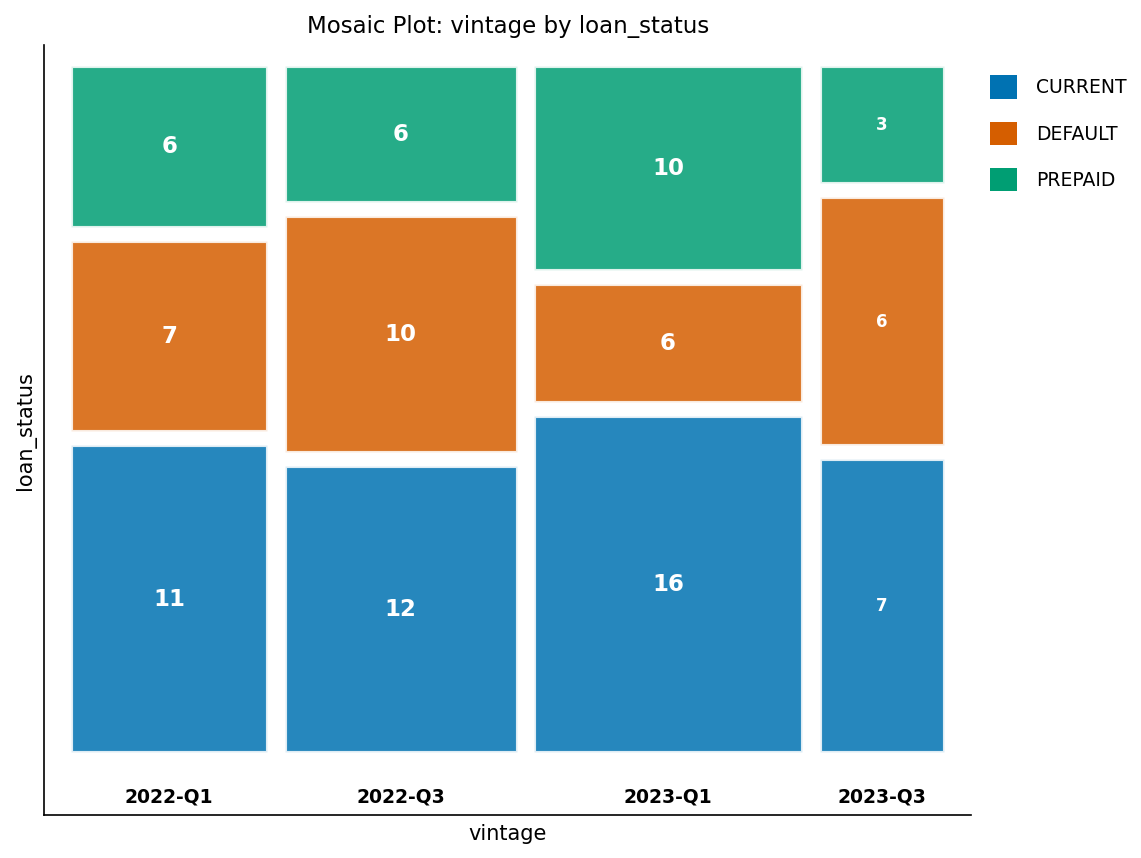

In [2]:
/* --------------------------------------------------------
   Baseline financial-ratio distributions by loan status
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.loan_profiles n mean std maxdec=3;
    KLASS loan_status;
    VARIABEL dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
KÖR;

/* --------------------------------------------------------
   Sample composition by vintage and status
   -------------------------------------------------------- */
PROCEDUR FREKVENSER data=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
KÖR;

---

### Kanonisk diskriminantanalys

Anpassa en gemensam (poolad) kanonisk diskriminantmodell över samtliga 100 kunder. `OUT=` skriver de kanoniska poängen per kund, `OUTSTAT=` fångar den kanoniska strukturen, klasscentroiderna och de kvadrerade Mahalanobisavstånden, och `DISTANCE` begär avstånden mellan grupperna. Den annonserade proceduren här är exakt den som körs: **PROC CANDISC**.


NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

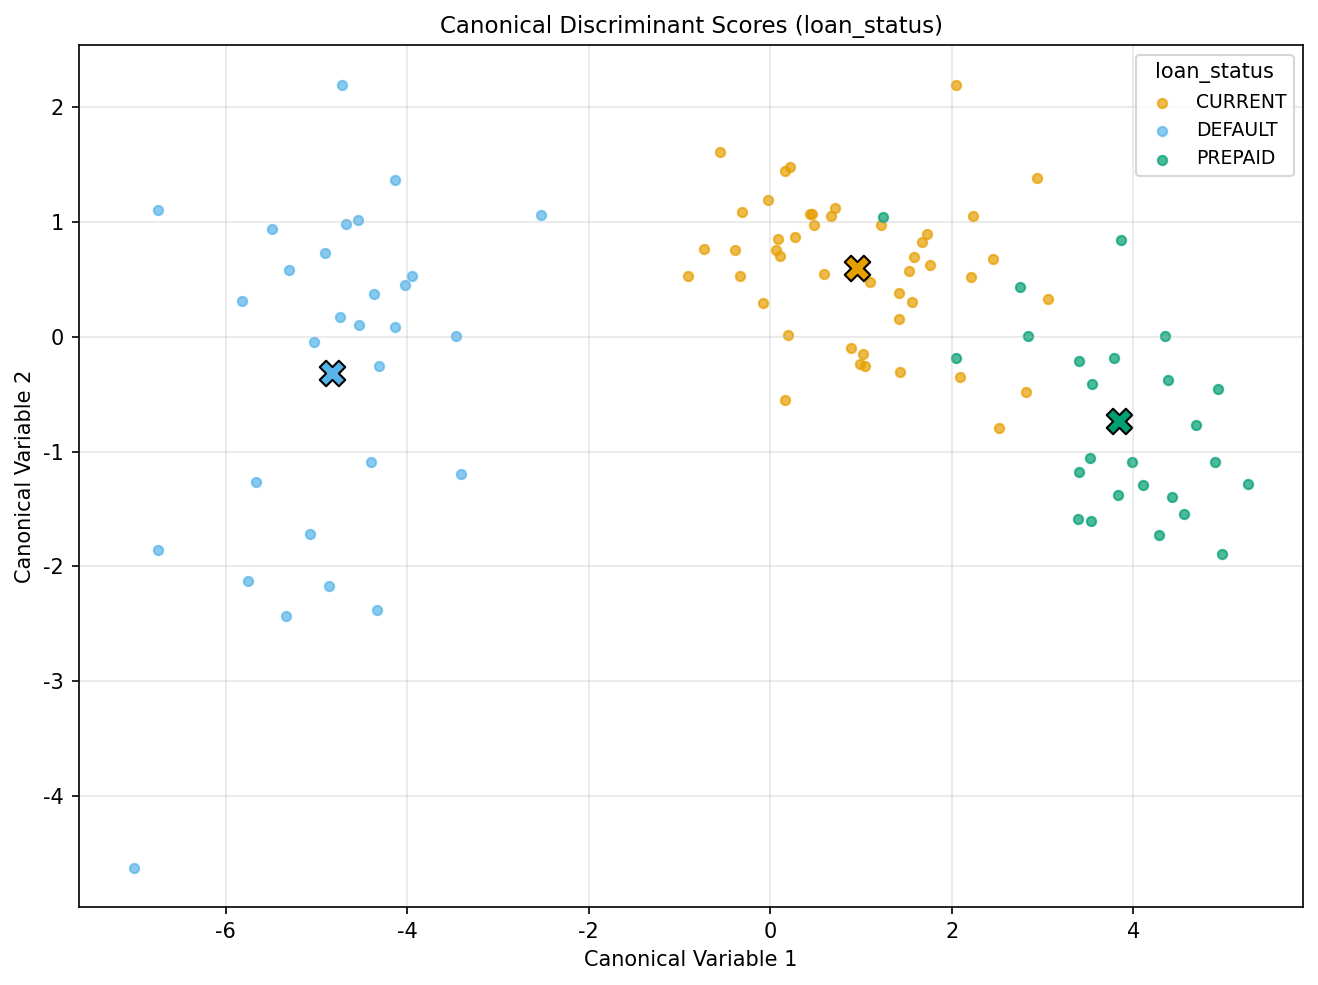

In [3]:
/* --------------------------------------------------------
   Canonical discriminant analysis of loan-status groups.
   OUT=    per-customer canonical scores (Can1, Can2)
   OUTSTAT= structure, class means, Mahalanobis distances
   -------------------------------------------------------- */
ODS UTDATA CanonicalCorrelations=work.can_corr;

PROCEDUR CANDISC data=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    KLASS loan_status;
    VARIABEL dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    TITEL 'Kanonisk riskdiskriminering av lånestatusgrupper';
KÖR;

ODS UTDATA CLOSE;

---

### Kanoniska korrelationer

Hur mycket av separationen mellan de tre grupperna som varje kanonisk dimension fångar.

In [4]:
PROCEDUR SKRIV data=work.can_corr noobs;
    TITEL 'Kanoniska korrelationer';
KÖR;

                                                Kanoniska korrelationer                                                 

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Kanonisk struktur (variabelladdningar)

Korrelationen mellan varje ursprungligt finansiellt nyckeltal och de två kanoniska dimensionerna — det är så dimensionerna tolkas.

In [5]:
PROCEDUR SKRIV data=work.can_stat noobs;
    DÄR _type_ = 'STRUCTUR';
    VARIABEL _name_ Can1 Can2;
    TITEL 'Poolad inomklasskanonisk struktur';
KÖR;

                                           Poolad inomklasskanonisk struktur                                            

            _NAME_       CAN1       CAN2
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Gruppcentroider och Mahalanobisavstånd

Klassmedelvärden på de kanoniska axlarna (gruppcentroiderna) och de kvadrerade Mahalanobisavstånden mellan varje par av grupper — grunden för kalibrering av riskpoäng.

In [6]:
PROCEDUR SKRIV data=work.can_stat noobs;
    DÄR _type_ IN ('CANMEAN' 'DIST');
    VARIABEL _type_ _name_ Can1 Can2;
    TITEL 'Gruppcentroider (CANMEAN) och kvadrerade Mahalanobisavstånd (DIST)';
KÖR;

                           Gruppcentroider (CANMEAN) och kvadrerade Mahalanobisavstånd (DIST)                           

 _TYPE_              _NAME_       CAN1       CAN2
CANMEAN  CURRENT              0.956102    0.59917
CANMEAN  DEFAULT             -4.826727  -0.316237
CANMEAN  PREPAID              3.839776  -0.735639
DIST     CURRENT to DEFAULT  34.279058          .
DIST     CURRENT to PREPAID  10.097273          .
DIST     DEFAULT to PREPAID  75.284092          .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Kanonisk diskriminantkarta

Varje kund inritad i det tvådimensionella kanoniska rummet, färgad efter lånestatus. Väl åtskilda kluster visar att de kanoniska poängen bär stark gruppinformation.

                           Gruppcentroider (CANMEAN) och kvadrerade Mahalanobisavstånd (DIST)                           




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


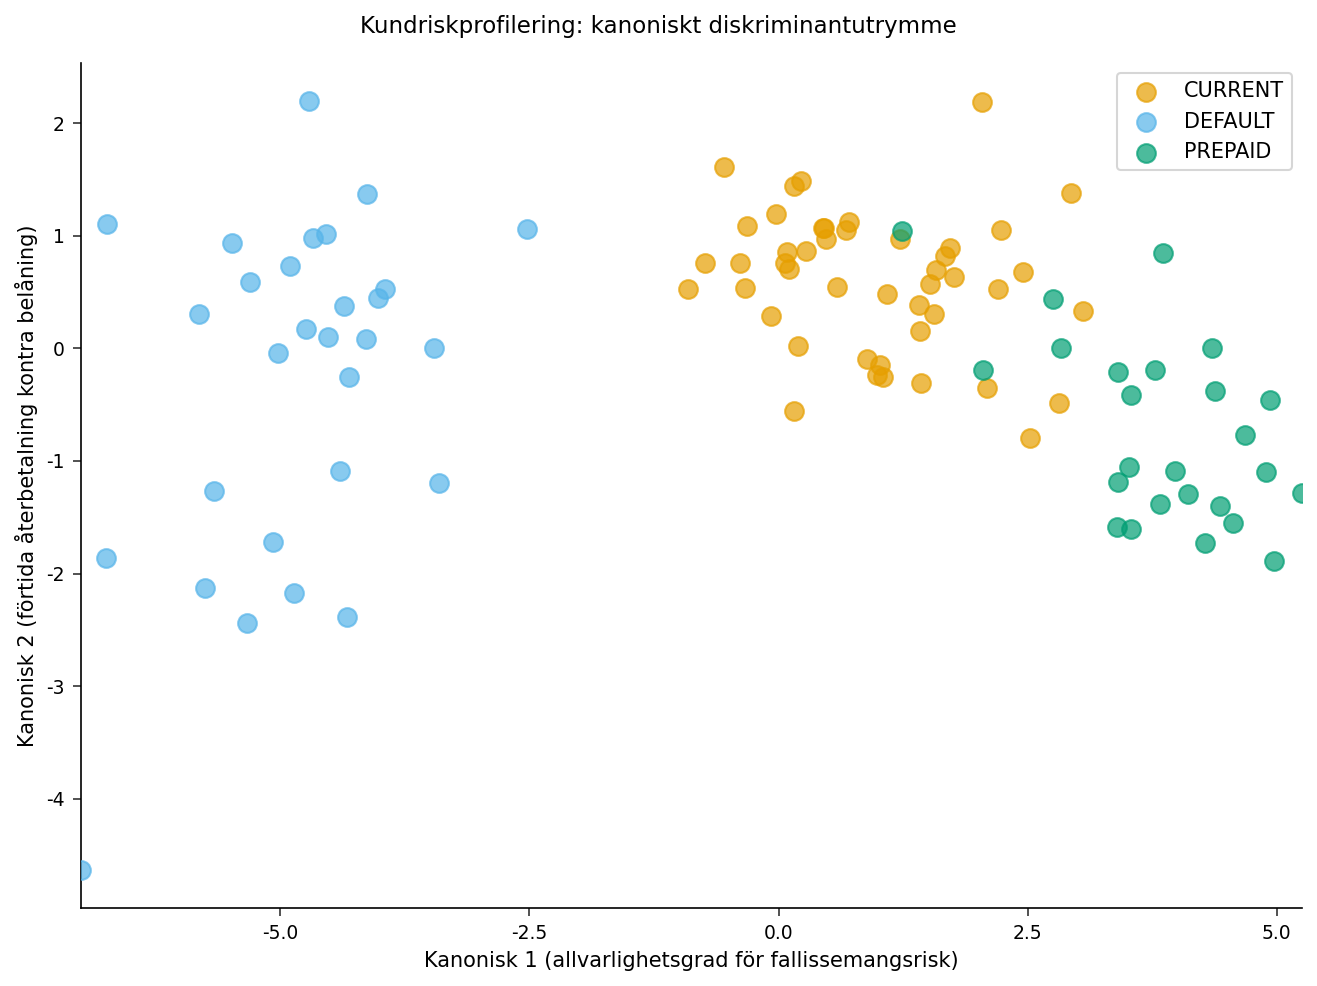

In [7]:
PROCEDUR SGPLOT data=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS ETIKETT='Kanonisk 1 (allvarlighetsgrad för fallissemangsrisk)';
    YAXIS ETIKETT='Kanonisk 2 (förtida återbetalning kontra belåning)';
    TITEL 'Kundriskprofilering: kanoniskt diskriminantutrymme';
KÖR;

---

### Tolkning

De två kanoniska dimensionerna separerar de tre lånestatusgrupperna skarpt inom detta urval med 100 kunder (46 löpande, 29 fallerade, 25 förtidsåterbetalda).

**Dimension 1 — allvarlighetsgrad i fallissemangsrisk (kanonisk korrelation 0.958, 91.8% delad varians).** Denna axel ensam står för den överväldigande majoriteten av gruppseparationen (egenvärde 11.20 mot 0.34 för den andra axeln). I den poolade kanoniska strukturen inom klasserna laddar den starkast på kreditutnyttjande (-0.595), skuld-i-förhållande-till-inkomst (-0.404), LTV (-0.370), antal månader i dröjsmål (-0.324) och betalning-i-förhållande-till-inkomst (-0.304) — varje mått på skuldsättning och belastning pekar åt samma håll. Eftersom laddningarna är negativa markerar låga (mer negativa) Can1-poäng låntagarna med högst risk. Klasscentroiderna bekräftar detta: fallerade konton ligger vid Can1 = -4.83, löpande konton vid +0.96 och förtidsåterbetalda konton vid +3.84, en ren monoton ordning från sämst till bäst kreditvärdighet.

**Dimension 2 — skuldsättning mot betalningsdröjsmål (kanonisk korrelation 0.503).** Den andra axeln kontrasterar LTV-kvot (+0.733) mot antal månader i dröjsmål (-0.700): den separerar låntagare som är högt skuldsatta men löpande från dem som bär på betalningsdröjsmål. Den förfinar bilden inom Can1 men bidrar med långt mindre separation, vilket de nästan lika Can2-centroiderna för de presterande grupperna (löpande +0.599, förtidsåterbetalda -0.736) visar.

**Gruppseparation.** De kvadrerade Mahalanobisavstånden mellan klassmedelvärdena kvantifierar gapen: DEFAULT-till-PREPAID är störst med 75.3, DEFAULT-till-CURRENT är 34.3 och CURRENT-till-PREPAID är minst med 10.1. De två presterande grupperna ligger därför närmare varandra än vad någon av dem gör till den fallerade gruppen, precis som en långivare skulle förvänta sig.

**Praktisk användning.** Den första kanoniska poängen fungerar som ett färdigt sammansatt riskindex: den komprimerar sex korrelerade nyckeltal till en väl åtskild dimension som ordnar kunderna från högst till lägst fallissemangsrisk. Portföljteam kan segmentera på brytpunkter i Can1, och Mahalanobisavstånden ger en principfast grund för att tilldela en ny sökande till närmaste statusgrupp under kalibrering av scorekort.

---

### Export för scoringmotorn

Bevara de kanoniska poängen per kund och datasetet med kanonisk statistik (som bär centroiderna och Mahalanobisavstånden) för nedströms kalibrering av scorekort.

In [8]:
/* --------------------------------------------------------
   Export canonical risk scores and canonical statistics
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>